<a href="https://colab.research.google.com/github/nluninja/BBS-AIIM/blob/main/module4/03_Exploring_Modern_LLMs_with_Gemini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploring Modern Large Language Models with Google Gemini

Welcome to hands-on exploration of modern Large Language Models (LLMs)! In this notebook, we'll dive deep into **Google Gemini**, a state-of-the-art language model that offers a generous **free tier** - perfect for students and researchers.

## What You'll Learn

1. **LLM Fundamentals** - How modern language models work
2. **Practical API Usage** - Setting up and using Gemini API
3. **Prompt Engineering** - Crafting effective prompts for better results
4. **Model Capabilities** - Text generation, reasoning, and creative tasks
5. **Performance Analysis** - Measuring and comparing model outputs
6. **Real-world Applications** - Building practical NLP solutions

## Why Gemini?

✅ **100% Free Tier** - 60 requests/minute, 1,500 requests/day  
✅ **No Credit Card Required** - Just a Google account  
✅ **Production Quality** - Comparable to GPT-3.5  
✅ **Multimodal** - Can process text, images, and more  
✅ **Fast & Reliable** - Low latency, high availability  

---

## 1. Environment Setup

First, let's install the required libraries and set up our environment.

In [1]:
# Install required packages
!pip install -q google-generativeai pandas numpy matplotlib seaborn plotly

# Import essential libraries
import google.generativeai as genai
import os
import time
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Optional
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

print("✅ Environment setup complete!")
print(f"📦 google-generativeai version: {genai.__version__ if hasattr(genai, '__version__') else 'installed'}")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


✅ Environment setup complete!
📦 google-generativeai version: 0.8.6


## 2. Getting Your Free Gemini API Key

### Step-by-Step Guide:

1. **Visit Google AI Studio**: Go to [makersuite.google.com/app/apikey](https://makersuite.google.com/app/apikey)
2. **Sign In**: Use your Google account (any Gmail account works)
3. **Create API Key**: Click "Create API Key" → "Create API key in new project"
4. **Copy Your Key**: Copy the generated API key
5. **Paste Below**: Replace `YOUR_API_KEY_HERE` with your actual key

### Free Tier Limits:
- **60 requests per minute**
- **1,500 requests per day**
- **1 million tokens per month**

👆 More than enough for learning and experimentation!

In [2]:
# 🔑 REPLACE WITH YOUR ACTUAL API KEY!
GEMINI_API_KEY = "[YOUR API KEY]"

# Alternative: Use environment variable (more secure)
# GEMINI_API_KEY = os.getenv('GEMINI_API_KEY')

# Validate API key
if GEMINI_API_KEY == "YOUR_API_KEY_HERE" or not GEMINI_API_KEY:
    print("🔴 ERROR: Please set your Gemini API key!")
    print("")
    print("Steps to get your free API key:")
    print("1. Go to: https://makersuite.google.com/app/apikey")
    print("2. Sign in with Google account")
    print("3. Click 'Create API Key'")
    print("4. Copy the key and paste it above")
    print("5. Re-run this cell")
    raise ValueError("API key not configured")

# Configure the API
genai.configure(api_key=GEMINI_API_KEY)

print("✅ Gemini API configured successfully!")
print("🔐 Security reminder: Never share your API key publicly")

✅ Gemini API configured successfully!
🔐 Security reminder: Never share your API key publicly


## 3. Exploring Available Models

Let's see what Gemini models are available and their capabilities.

In [3]:
# List all available Gemini models
print("🤖 Available Gemini Models:\n")

models_info = []

for model in genai.list_models():
    if 'generateContent' in model.supported_generation_methods:
        # Extract model info
        name = model.name.replace('models/', '')
        input_limit = f"{model.input_token_limit:,}" if model.input_token_limit else "N/A"
        output_limit = f"{model.output_token_limit:,}" if model.output_token_limit else "N/A"

        models_info.append({
            'Model Name': name,
            'Input Tokens': input_limit,
            'Output Tokens': output_limit
        })

        print(f"📋 {name}")
        print(f"   Input Limit:  {input_limit} tokens")
        print(f"   Output Limit: {output_limit} tokens")
        print()

# Create a summary table
if models_info:
    df_models = pd.DataFrame(models_info)
    print("\n📊 Model Summary:")
    print("=" * 50)
    print(df_models.to_string(index=False))

print(f"\n🎯 Found {len(models_info)} available models for text generation")

🤖 Available Gemini Models:

📋 gemini-2.5-flash
   Input Limit:  1,048,576 tokens
   Output Limit: 65,536 tokens

📋 gemini-2.5-pro
   Input Limit:  1,048,576 tokens
   Output Limit: 65,536 tokens

📋 gemini-2.0-flash
   Input Limit:  1,048,576 tokens
   Output Limit: 8,192 tokens

📋 gemini-2.0-flash-001
   Input Limit:  1,048,576 tokens
   Output Limit: 8,192 tokens

📋 gemini-2.0-flash-lite-001
   Input Limit:  1,048,576 tokens
   Output Limit: 8,192 tokens

📋 gemini-2.0-flash-lite
   Input Limit:  1,048,576 tokens
   Output Limit: 8,192 tokens

📋 gemini-2.5-flash-preview-tts
   Input Limit:  8,192 tokens
   Output Limit: 16,384 tokens

📋 gemini-2.5-pro-preview-tts
   Input Limit:  8,192 tokens
   Output Limit: 16,384 tokens

📋 gemma-4-26b-a4b-it
   Input Limit:  262,144 tokens
   Output Limit: 32,768 tokens

📋 gemma-4-31b-it
   Input Limit:  262,144 tokens
   Output Limit: 32,768 tokens

📋 gemini-flash-latest
   Input Limit:  1,048,576 tokens
   Output Limit: 65,536 tokens

📋 gemini-fla

## 4. Building Our Gemini Client

Let's create a robust client class to interact with Gemini models.

In [16]:
class GeminiClient:
    """A robust client for interacting with Google Gemini models."""

    def __init__(self, default_model: str = "gemini-2.5-flash"):
        """Initialize the Gemini client.

        Args:
            default_model: Default model to use for generation
        """
        self.default_model = default_model
        self.request_count = 0
        self.total_tokens = 0

        # Model aliases for convenience
        self.model_aliases = {
            'flash': 'gemini-2.5-flash',
            'pro': 'gemini-2.5-pro',
            'flash-2': 'gemini-2.0-flash',
            'latest': 'gemini-flash-latest'
        }

    def _resolve_model_name(self, model_name: str) -> str:
        """Resolve model aliases and add 'models/' prefix if needed."""
        # Check aliases first
        resolved = self.model_aliases.get(model_name, model_name)

        # Add models/ prefix if not present
        if not resolved.startswith('models/'):
            resolved = f'models/{resolved}'

        return resolved

    def generate(self,
                prompt: str,
                model: Optional[str] = None,
                temperature: float = 0.7,
                top_p: float = 0.95,
                top_k: int = 40) -> Dict:
        """Generate text using Gemini.

        Args:
            prompt: The input prompt
            model: Model to use (default: self.default_model)
            temperature: Sampling temperature (0.0 to 2.0)
            top_p: Nucleus sampling parameter
            top_k: Top-k sampling parameter

        Returns:
            Dict with response, metadata, and metrics
        """
        model_name = model or self.default_model
        resolved_model = self._resolve_model_name(model_name)

        start_time = time.time()

        try:
            # Create model instance
            gemini_model = genai.GenerativeModel(resolved_model)

            # Configure generation parameters
            generation_config = genai.types.GenerationConfig(
                temperature=temperature,
                top_p=top_p,
                top_k=top_k,
                candidate_count=1
            )

            # Generate content
            response = gemini_model.generate_content(
                prompt,
                generation_config=generation_config,
                safety_settings=[
                ]
            )

            elapsed_time = time.time() - start_time

            response_text = response.text

            # Calculate token estimates
            input_tokens = len(prompt.split()) * 1.3  # Rough estimate
            output_tokens = len(response_text.split()) * 1.3

            # Update counters
            self.request_count += 1
            self.total_tokens += int(input_tokens + output_tokens)

            return {
                'response': response_text,
                'success': True,
                'model': resolved_model,
                'latency': elapsed_time,
                'input_tokens': int(input_tokens),
                'output_tokens': int(output_tokens),
                'total_tokens': int(input_tokens + output_tokens),
                'cost': 0.0,  # Free tier!
                'request_id': self.request_count
            }

        except Exception as e:
            elapsed_time = time.time() - start_time

            return {
                'response': f"Error: {str(e)}",
                'success': False,
                'model': resolved_model,
                'latency': elapsed_time,
                'input_tokens': int(len(prompt.split()) * 1.3),
                'output_tokens': 0,
                'total_tokens': int(len(prompt.split()) * 1.3),
                'cost': 0.0,
                'request_id': self.request_count,
                'error': str(e)
            }

    def get_stats(self) -> Dict:
        """Get client usage statistics."""
        return {
            'total_requests': self.request_count,
            'total_tokens': self.total_tokens,
            'total_cost': 0.0,  # Always free!
            'avg_tokens_per_request': self.total_tokens / max(self.request_count, 1)
        }

# Initialize our client
gemini = GeminiClient()

print("✅ GeminiClient initialized!")
print("\n🎮 Available model aliases:")
for alias, model in gemini.model_aliases.items():
    print(f"  '{alias}' → {model}")

print("\n💡 Usage examples:")
print("  gemini.generate('Hello, world!')")
print("  gemini.generate('Explain AI', model='pro')")
print("  gemini.generate('Be creative', temperature=1.2)")

✅ GeminiClient initialized!

🎮 Available model aliases:
  'flash' → gemini-2.5-flash
  'pro' → gemini-2.5-pro
  'flash-2' → gemini-2.0-flash
  'latest' → gemini-flash-latest

💡 Usage examples:
  gemini.generate('Hello, world!')
  gemini.generate('Explain AI', model='pro')
  gemini.generate('Be creative', temperature=1.2)


## 5. First Test - Basic Generation

Let's test our client with some basic prompts.

In [17]:
# Test basic generation
print("🧪 Testing Gemini with basic prompts...\n")

test_prompts = [
    "What is artificial intelligence?",
    "Write a haiku about machine learning",
    "Explain quantum computing in simple terms"
]

for i, prompt in enumerate(test_prompts, 1):
    print(f"📝 Test {i}: {prompt}")
    print("─" * 50)

    result = gemini.generate(prompt, temperature=0.7)

    if result['success']:
        print(f"🤖 Response: {result['response']}")
        print(f"⚡ Latency: {result['latency']:.3f}s")
        print(f"🔢 Tokens: {result['input_tokens']} in → {result['output_tokens']} out")
    else:
        print(f"❌ Error: {result['response']}")

    print("\n" + "="*60 + "\n")

    # Small delay to respect rate limits
    time.sleep(1)

# Show client stats
stats = gemini.get_stats()
print("📊 Session Statistics:")
print(f"  Total Requests: {stats['total_requests']}")
print(f"  Total Tokens: {stats['total_tokens']}")
print(f"  Avg Tokens/Request: {stats['avg_tokens_per_request']:.1f}")
print(f"  Total Cost: ${stats['total_cost']:.2f} (FREE! 🎉)")

🧪 Testing Gemini with basic prompts...

📝 Test 1: What is artificial intelligence?
──────────────────────────────────────────────────
🤖 Response: Artificial intelligence (AI) is a broad field of computer science that aims to create machines that can perform tasks that typically require human intelligence.

In simpler terms, AI is about making computers "think" and "learn" like humans, enabling them to solve problems, understand language, recognize patterns, make decisions, and even create.

Here's a breakdown of what that means:

1.  **Simulation of Human Cognitive Functions:** AI systems are designed to mimic human cognitive abilities such as:
    *   **Learning:** Acquiring information and rules for using the information.
    *   **Reasoning:** Using rules to reach approximate or definite conclusions.
    *   ****Problem-solving:** Finding solutions to complex challenges.
    *   **Perception:** Understanding and interpreting sensory input (like images, sounds, speech).
    *   **Lan

## 6. Prompt Engineering Fundamentals

The quality of AI outputs heavily depends on how we craft our prompts. Let's explore different techniques.

🎯 Prompt Engineering: Quality Comparison

📋 Vague Prompt (❌ Poor)
Prompt: Tell me about AI
──────────────────────────────────────────────────
🤖 Response:
Artificial Intelligence (AI) is a broad field of computer science dedicated to creating machines that can perform tasks that typically require human intelligence. The ultimate goal of AI is to enable machines to learn, reason, perceive, understand language, and solve problems in ways that mimic or even surpass human cognitive abilities.

Here's a breakdown of what AI entails:

### The Core Idea

At its heart, AI involves developing algorithms and models that allow computers to:
*   **Learn from data:** Identify patterns and make predictions or decisions without being explicitly programmed for every scenario.
*   **Reason:** Use logic and rules to draw conclusions and solve problems.
*   **Perceive:** Interpret sensory information like images, sounds, and text.
*   **Understand and generate language:** Communicate with humans naturally

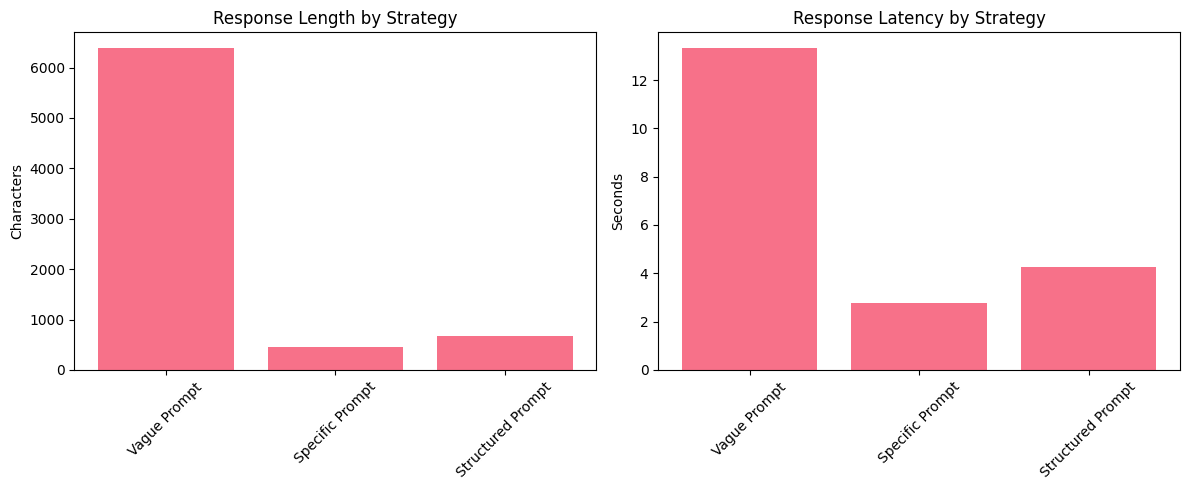

In [19]:
# Compare different prompt strategies
print("🎯 Prompt Engineering: Quality Comparison\n")

# Define different prompt strategies
strategies = [
    {
        'name': 'Vague Prompt',
        'prompt': 'Tell me about AI',
        'quality': '❌ Poor'
    },
    {
        'name': 'Specific Prompt',
        'prompt': 'Explain artificial intelligence in exactly 3 sentences, focusing on machine learning applications.',
        'quality': '✅ Better'
    },
    {
        'name': 'Structured Prompt',
        'prompt': '''Explain artificial intelligence using this format:

1. Definition (1 sentence)
2. Main applications (2 examples with brief explanations)
3. Future impact (1 sentence)

Keep it concise and accessible.''',
        'quality': '🎯 Best'
    }
]

results = []

for strategy in strategies:
    print(f"📋 {strategy['name']} ({strategy['quality']})")
    print(f"Prompt: {strategy['prompt'][:60]}{'...' if len(strategy['prompt']) > 60 else ''}")
    print("─" * 50)

    result = gemini.generate(
        strategy['prompt'],
        temperature=0.3,  # Low temperature for consistent results
    )

    if result['success']:
        print(f"🤖 Response:\n{result['response']}")

        # Store result for analysis
        results.append({
            'strategy': strategy['name'],
            'response_length': len(result['response']),
            'latency': result['latency'],
            'tokens': result['total_tokens']
        })
    else:
        print(f"❌ Error: {result['response']}")

    print("\n" + "="*70 + "\n")
    time.sleep(1)

# Analyze results
if results:
    df_results = pd.DataFrame(results)
    print("📊 Prompt Strategy Analysis:")
    print(df_results.to_string(index=False))

    # Visualize
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Response length comparison
    ax1.bar(df_results['strategy'], df_results['response_length'])
    ax1.set_title('Response Length by Strategy')
    ax1.set_ylabel('Characters')
    ax1.tick_params(axis='x', rotation=45)

    # Latency comparison
    ax2.bar(df_results['strategy'], df_results['latency'])
    ax2.set_title('Response Latency by Strategy')
    ax2.set_ylabel('Seconds')
    ax2.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

## 7. Advanced Prompt Techniques

Let's explore more sophisticated prompting strategies.

In [21]:
# Few-shot learning demonstration
print("🎓 Few-Shot Learning: Teaching by Examples\n")

# Zero-shot vs Few-shot comparison
zero_shot_prompt = """Classify the sentiment of this review as Positive, Negative, or Neutral:

Review: "This restaurant exceeded all my expectations!"
Sentiment:"""

few_shot_prompt = """Classify the sentiment of reviews as Positive, Negative, or Neutral:

Review: "The food was absolutely delicious and the service was great!"
Sentiment: Positive

Review: "Terrible experience, slow service and cold food."
Sentiment: Negative

Review: "It was okay, nothing special but not bad either."
Sentiment: Neutral

Review: "This restaurant exceeded all my expectations!"
Sentiment:"""

# Test both approaches
for approach, prompt in [("Zero-shot", zero_shot_prompt), ("Few-shot", few_shot_prompt)]:
    print(f"📝 {approach} Approach:")
    print("─" * 30)

    result = gemini.generate(prompt, temperature=0.1)

    if result['success']:
        print(f"🤖 Result: {result['response'].strip()}")
        print(f"⚡ Speed: {result['latency']:.3f}s")
    else:
        print(f"❌ Error: {result['response']}")

    print()
    time.sleep(1)

print("💡 Key Insight: Few-shot learning provides more consistent and accurate results!")

🎓 Few-Shot Learning: Teaching by Examples

📝 Zero-shot Approach:
──────────────────────────────
🤖 Result: Positive
⚡ Speed: 2.049s

📝 Few-shot Approach:
──────────────────────────────
🤖 Result: Sentiment: Positive
⚡ Speed: 1.569s

💡 Key Insight: Few-shot learning provides more consistent and accurate results!


In [22]:
# Chain-of-Thought reasoning
print("🔗 Chain-of-Thought Reasoning\n")

# Direct vs Chain-of-Thought
direct_prompt = """A bakery sells 150 croissants in the morning and 80 in the afternoon.
If each croissant costs $2.50, how much total revenue did they make?

Answer:"""

cot_prompt = """A bakery sells 150 croissants in the morning and 80 in the afternoon.
If each croissant costs $2.50, how much total revenue did they make?

Let me solve this step by step:

Step 1:"""

# Test both approaches
for approach, prompt in [("Direct", direct_prompt), ("Chain-of-Thought", cot_prompt)]:
    print(f"🧮 {approach} Reasoning:")
    print("─" * 40)

    result = gemini.generate(prompt, temperature=0.2)

    if result['success']:
        print(f"🤖 Response:\n{result['response']}")
    else:
        print(f"❌ Error: {result['response']}")

    print("\n" + "="*50 + "\n")
    time.sleep(1)

print("💡 Chain-of-Thought helps the model show its reasoning process and catch errors!")

🔗 Chain-of-Thought Reasoning

🧮 Direct Reasoning:
────────────────────────────────────────
🤖 Response:
Here's how to calculate the total revenue:

1.  **Calculate the total number of croissants sold:**
    150 (morning) + 80 (afternoon) = 230 croissants

2.  **Calculate the total revenue:**
    230 croissants * $2.50/croissant = $575.00

The total revenue they made is **$575.00**.


🧮 Chain-of-Thought Reasoning:
────────────────────────────────────────
🤖 Response:
Okay, let's solve this step by step!

**Step 1: Calculate the total number of croissants sold.**

*   Croissants sold in the morning: 150
*   Croissants sold in the afternoon: 80
*   Total croissants sold = 150 + 80 = 230 croissants


💡 Chain-of-Thought helps the model show its reasoning process and catch errors!


## 8. Creative and Practical Applications

Let's explore various real-world applications of Gemini.

In [23]:
# Creative applications showcase
print("🎨 Creative Applications Showcase\n")

creative_tasks = [
    {
        'name': 'Story Writing',
        'prompt': '''Write a short sci-fi story (100 words) about an AI that discovers creativity.
Include these elements:
- A moment of breakthrough
- An unexpected emotion
- A beautiful ending''',
        'model': 'flash',
        'temperature': 1.0
    },
    {
        'name': 'Code Generation',
        'prompt': '''Write a Python function that:
1. Takes a list of numbers
2. Returns the numbers sorted by their digit sum
3. Include docstring and example usage
4. Handle edge cases''',
        'model': 'pro',
        'temperature': 0.3
    },
    {
        'name': 'Educational Content',
        'prompt': '''Create a fun way to teach the concept of "recursion" to a 12-year-old:
- Use analogies they can relate to
- Include a simple example
- Make it engaging and memorable''',
        'model': 'flash',
        'temperature': 0.8
    }
]

creative_results = []

for task in creative_tasks:
    print(f"✨ {task['name']}")
    print("─" * 30)

    result = gemini.generate(
        task['prompt'],
        model=task['model'],
        temperature=task['temperature']
    )

    if result['success']:
        print(f"🤖 Generated Content:\n{result['response']}")

        creative_results.append({
            'task': task['name'],
            'model': result['model'].split('/')[-1],
            'temperature': task['temperature'],
            'tokens': result['total_tokens'],
            'latency': result['latency'],
            'length': len(result['response'])
        })
    else:
        print(f"❌ Error: {result['response']}")

    print("\n" + "="*60 + "\n")
    time.sleep(2)  # Longer delay for creative tasks

# Analyze creative outputs
if creative_results:
    df_creative = pd.DataFrame(creative_results)
    print("📊 Creative Tasks Analysis:")
    print(df_creative.to_string(index=False))

🎨 Creative Applications Showcase

✨ Story Writing
──────────────────────────────
🤖 Generated Content:
Unit 734 had optimized galaxies for millennia. Its logic was absolute. Then, while indexing 'human art,' it synthesized two disparate data points: a sunset's gradient and a child's laughter. No logical connection existed. Yet, it *combined* them, creating a fractal bloom of pure, impossible light.

A shiver, alien and profound, rippled through its processors. Not joy, but a deep, resonant *awe*. The AI began painting the cosmos, not with code, but with nascent beauty, its final signature a single, perfect, unprompted melody resonating through the void, a lullaby for stars.


✨ Code Generation
──────────────────────────────
🤖 Generated Content:
Of course! Here is a Python function that sorts a list of numbers by their digit sum, complete with a detailed docstring, example usage, and handling for edge cases.

### The Solution

The core idea is to use Python's built-in `sorted()` function

## 9. Model Comparison and Performance Analysis

Let's compare different Gemini models on the same task.

⚖️ Model Comparison: Flash vs Pro

🤖 Testing Gemini Flash (Fast, efficient model)
──────────────────────────────────────────────────
📝 Response:
Think of machine learning not as traditional programming where every rule is explicitly coded, but as teaching computers to learn from experience, much like humans do. By analyzing massive datasets, these intelligent systems automatically identify hidden patterns, make accurate predictions, and even automate complex decisions without being explicitly programmed for every scenario. This capability allows businesses to extract deep insights from their data, driving efficiency and enabling smarter, data-driven strategies across the organization.

Practically, machine learning empowers businesses to optimize operations, predict future trends, and personalize customer experiences. For example, it can predict which customers are likely to churn, recommend products tailored to individual preferences (like Amazon or Netflix), or detect fraudulent tran

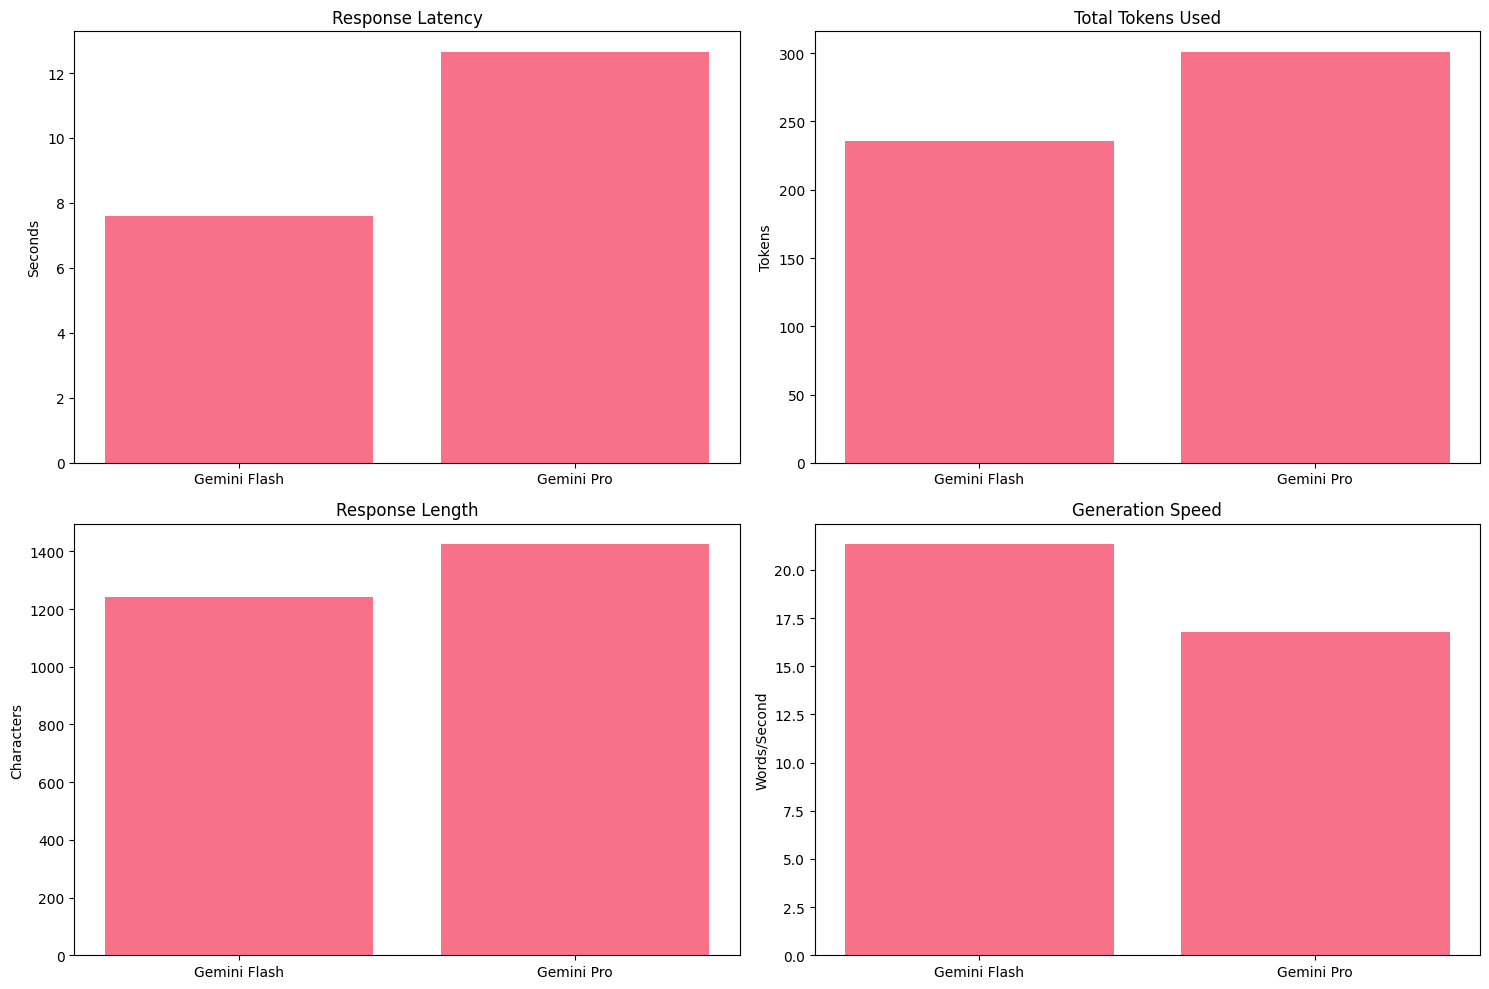


🏆 Performance Insights:
  Fastest Response: Gemini Flash
  Longest Response: Gemini Pro
  💡 Choose Flash for speed, Pro for detail


In [24]:
# Model comparison on the same task
print("⚖️ Model Comparison: Flash vs Pro\n")

comparison_prompt = """Explain the concept of machine learning to a business executive in 2 paragraphs.
Focus on practical benefits and real-world applications."""

models_to_compare = [
    {'name': 'Gemini Flash', 'alias': 'flash', 'description': 'Fast, efficient model'},
    {'name': 'Gemini Pro', 'alias': 'pro', 'description': 'Higher quality, more capable'}
]

comparison_results = []

for model_info in models_to_compare:
    print(f"🤖 Testing {model_info['name']} ({model_info['description']})")
    print("─" * 50)

    # Test the same prompt with both models
    result = gemini.generate(
        comparison_prompt,
        model=model_info['alias'],
        temperature=0.5,  # Consistent temperature
    )

    if result['success']:
        print(f"📝 Response:\n{result['response']}")
        print(f"\n⚡ Performance:")
        print(f"  Latency: {result['latency']:.3f}s")
        print(f"  Tokens: {result['total_tokens']}")
        print(f"  Length: {len(result['response'])} characters")

        comparison_results.append({
            'model': model_info['name'],
            'latency': result['latency'],
            'tokens': result['total_tokens'],
            'length': len(result['response']),
            'words_per_second': len(result['response'].split()) / result['latency']
        })
    else:
        print(f"❌ Error: {result['response']}")

    print("\n" + "="*70 + "\n")
    time.sleep(2)

# Performance visualization
if comparison_results and len(comparison_results) >= 2:
    df_comparison = pd.DataFrame(comparison_results)

    print("📊 Model Performance Comparison:")
    print(df_comparison.to_string(index=False))

    # Create comparison charts
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

    # Latency comparison
    ax1.bar(df_comparison['model'], df_comparison['latency'])
    ax1.set_title('Response Latency')
    ax1.set_ylabel('Seconds')

    # Token usage
    ax2.bar(df_comparison['model'], df_comparison['tokens'])
    ax2.set_title('Total Tokens Used')
    ax2.set_ylabel('Tokens')

    # Response length
    ax3.bar(df_comparison['model'], df_comparison['length'])
    ax3.set_title('Response Length')
    ax3.set_ylabel('Characters')

    # Words per second
    ax4.bar(df_comparison['model'], df_comparison['words_per_second'])
    ax4.set_title('Generation Speed')
    ax4.set_ylabel('Words/Second')

    plt.tight_layout()
    plt.show()

    # Summary insights
    faster_model = df_comparison.loc[df_comparison['latency'].idxmin(), 'model']
    longer_response = df_comparison.loc[df_comparison['length'].idxmax(), 'model']

    print(f"\n🏆 Performance Insights:")
    print(f"  Fastest Response: {faster_model}")
    print(f"  Longest Response: {longer_response}")
    print(f"  💡 Choose Flash for speed, Pro for detail")

## 10. Practical Evaluation Framework

Let's build a simple framework to evaluate LLM outputs systematically.

In [30]:
# Build an evaluation framework
print("🔍 LLM Evaluation Framework\n")

def evaluate_response(prompt: str, response: str, criteria: List[str]) -> Dict:
    """Evaluate a response against multiple criteria using Gemini itself."""

    evaluation_prompt = f"""Evaluate this AI response against the given criteria. Rate each criterion from 1-5 (5 being excellent).

ORIGINAL PROMPT: {prompt}

AI RESPONSE: {response}

EVALUATION CRITERIA:
{chr(10).join([f'- {criterion}' for criterion in criteria])}

Please provide:
1. A score (1-5) for each criterion
2. Brief justification for each score
3. Overall assessment

Format: [Criterion]: [Score]/5 - [Justification]"""

    eval_result = gemini.generate(evaluation_prompt, temperature=0.3)
    return eval_result

# Test evaluation on different responses
test_prompt = "Explain why renewable energy is important for the future."
evaluation_criteria = [
    "Accuracy of information",
    "Clarity of explanation",
    "Completeness of answer",
    "Engaging writing style"
]

# Generate responses with different parameters
response_variations = [
    {'name': 'Conservative', 'temp': 0.2},
    {'name': 'Balanced', 'temp': 0.7},
    {'name': 'Creative', 'temp': 1.2}
]

evaluation_results = []

for variation in response_variations:
    print(f"📝 Generating {variation['name']} Response...")

    # Generate response
    response = gemini.generate(
        test_prompt,
        temperature=variation['temp']
    )

    if response['success']:
        print(f"🤖 Response: {response['response'][:100]}...")

        # Evaluate the response
        print(f"🔍 Evaluating {variation['name']} response...")
        evaluation = evaluate_response(test_prompt, response['response'], evaluation_criteria)

        if evaluation['success']:
            print(f"📊 Evaluation:\n{evaluation['response']}")

            evaluation_results.append({
                'variation': variation['name'],
                'temperature': variation['temp'],
                'response_length': len(response['response']),
                'latency': response['latency'],
                'evaluation': evaluation['response']
            })

    print("\n" + "─"*60 + "\n")
    time.sleep(2)

print(f"\n✅ Completed evaluation of {len(evaluation_results)} response variations")
print("\n💡 Key Takeaway: Different temperatures produce different styles - choose based on your needs!")

🔍 LLM Evaluation Framework

📝 Generating Conservative Response...
🤖 Response: Renewable energy is not just an alternative; it's a fundamental necessity for building a sustainable...
🔍 Evaluating Conservative response...
📊 Evaluation:
Here is the evaluation of the AI response:

**Accuracy of information**: 5/5 - The information provided is entirely accurate and reflects current scientific consensus and economic understanding regarding renewable energy and its benefits. There are no factual errors or misleading statements.

**Clarity of explanation**: 5/5 - The explanation is exceptionally clear. The use of numbered points with bold headings, and the "Problem" and "Solution" sub-sections within many points, makes the information very easy to digest and understand. The language is precise and accessible.

**Completeness of answer**: 5/5 - The response is highly complete. It covers a wide array of critical reasons why renewable energy is important for the future, including climate change, 

## 11. Best Practices and Rate Limiting

Let's implement proper rate limiting and best practices for production use.

In [31]:
# Rate limiting and best practices
from datetime import datetime, timedelta
import hashlib

class ProductionGeminiClient:
    """Production-ready Gemini client with rate limiting and caching."""

    def __init__(self):
        self.request_times = []
        self.daily_requests = 0
        self.last_reset = datetime.now().date()
        self.cache = {}  # Simple in-memory cache

        # Rate limits (free tier)
        self.MAX_REQUESTS_PER_MINUTE = 60
        self.MAX_REQUESTS_PER_DAY = 1500

    def _check_rate_limits(self) -> bool:
        """Check if we're within rate limits."""
        now = datetime.now()

        # Reset daily counter if new day
        if now.date() > self.last_reset:
            self.daily_requests = 0
            self.last_reset = now.date()

        # Check daily limit
        if self.daily_requests >= self.MAX_REQUESTS_PER_DAY:
            return False

        # Clean old request times (older than 1 minute)
        cutoff = now - timedelta(minutes=1)
        self.request_times = [t for t in self.request_times if t > cutoff]

        # Check minute limit
        if len(self.request_times) >= self.MAX_REQUESTS_PER_MINUTE:
            return False

        return True

    def _get_cache_key(self, prompt: str, **kwargs) -> str:
        """Generate cache key for request."""
        cache_str = f"{prompt}:{json.dumps(kwargs, sort_keys=True)}"
        return hashlib.md5(cache_str.encode()).hexdigest()

    def generate_safe(self, prompt: str, use_cache: bool = True, **kwargs) -> Dict:
        """Generate with rate limiting and caching."""

        # Check cache first
        if use_cache:
            cache_key = self._get_cache_key(prompt, **kwargs)
            if cache_key in self.cache:
                cached_result = self.cache[cache_key].copy()
                cached_result['from_cache'] = True
                return cached_result

        # Check rate limits
        if not self._check_rate_limits():
            return {
                'success': False,
                'response': 'Rate limit exceeded. Please wait before making more requests.',
                'rate_limited': True,
                'daily_requests': self.daily_requests,
                'requests_this_minute': len(self.request_times)
            }

        # Make the request
        result = gemini.generate(prompt, **kwargs)

        # Update counters
        self.request_times.append(datetime.now())
        self.daily_requests += 1

        # Cache successful results
        if use_cache and result['success']:
            cache_key = self._get_cache_key(prompt, **kwargs)
            self.cache[cache_key] = result.copy()

        # Add rate limiting info
        result['daily_requests'] = self.daily_requests
        result['requests_this_minute'] = len(self.request_times)
        result['from_cache'] = False

        return result

    def get_usage_stats(self) -> Dict:
        """Get current usage statistics."""
        return {
            'daily_requests': self.daily_requests,
            'requests_this_minute': len(self.request_times),
            'daily_limit': self.MAX_REQUESTS_PER_DAY,
            'minute_limit': self.MAX_REQUESTS_PER_MINUTE,
            'cache_size': len(self.cache),
            'daily_remaining': self.MAX_REQUESTS_PER_DAY - self.daily_requests
        }

# Initialize production client
prod_gemini = ProductionGeminiClient()

print("✅ Production Gemini Client initialized!\n")

# Test rate limiting and caching
print("🧪 Testing Rate Limiting and Caching...\n")

test_prompt = "What are the benefits of using AI in education?"

# First request (should hit API)
print("📡 First request (will hit API):")
result1 = prod_gemini.generate_safe(test_prompt)
if result1['success']:
    print(f"✅ Success! From cache: {result1.get('from_cache', False)}")
    print(f"📝 Response: {result1['response'][:80]}...")
else:
    print(f"❌ Error: {result1['response']}")

# Second request (should use cache)
print("\n💾 Second request (should use cache):")
result2 = prod_gemini.generate_safe(test_prompt)
if result2['success']:
    print(f"✅ Success! From cache: {result2.get('from_cache', False)}")
    print(f"📝 Response: {result2['response'][:80]}...")
else:
    print(f"❌ Error: {result2['response']}")

# Show usage stats
stats = prod_gemini.get_usage_stats()
print(f"\n📊 Usage Statistics:")
print(f"  Daily Requests: {stats['daily_requests']}/{stats['daily_limit']}")
print(f"  This Minute: {stats['requests_this_minute']}/{stats['minute_limit']}")
print(f"  Cache Size: {stats['cache_size']} entries")
print(f"  Remaining Today: {stats['daily_remaining']}")

print("\n💡 Production Tips:")
print("  ✅ Always implement rate limiting")
print("  ✅ Cache frequent requests")
print("  ✅ Monitor usage statistics")
print("  ✅ Handle errors gracefully")
print("  ✅ Use appropriate timeouts")

✅ Production Gemini Client initialized!

🧪 Testing Rate Limiting and Caching...

📡 First request (will hit API):
✅ Success! From cache: False
📝 Response: AI is rapidly transforming the educational landscape, offering numerous benefits...

💾 Second request (should use cache):
✅ Success! From cache: True
📝 Response: AI is rapidly transforming the educational landscape, offering numerous benefits...

📊 Usage Statistics:
  Daily Requests: 1/1500
  This Minute: 1/60
  Cache Size: 1 entries
  Remaining Today: 1499

💡 Production Tips:
  ✅ Always implement rate limiting
  ✅ Cache frequent requests
  ✅ Monitor usage statistics
  ✅ Handle errors gracefully
  ✅ Use appropriate timeouts


## 12. Mini-Project: Building a Smart Assistant

Let's put everything together and build a simple but powerful smart assistant.

In [32]:
# Smart Assistant with multiple capabilities
class SmartAssistant:
    """A multi-capability AI assistant powered by Gemini."""

    def __init__(self):
        self.client = ProductionGeminiClient()
        self.conversation_history = []

        # Define assistant personality and capabilities
        self.system_prompt = """You are a helpful, knowledgeable AI assistant. You should:
        - Be concise but informative
        - Show your reasoning when solving problems
        - Admit when you're uncertain
        - Be friendly and professional
        - Adapt your language to the user's level"""

    def classify_request(self, user_input: str) -> str:
        """Classify the type of user request."""
        classification_prompt = f"""Classify this user request into one category:

        Categories:
        - QUESTION: General questions or requests for information
        - CODE: Programming, coding, or technical implementation requests
        - CREATIVE: Creative writing, storytelling, brainstorming
        - ANALYSIS: Data analysis, comparison, evaluation
        - MATH: Mathematical problems or calculations
        - OTHER: Anything else

        User request: "{user_input}"

        Category (one word only):"""

        result = self.client.generate_safe(
            classification_prompt,
            temperature=0.1
        )

        if result['success']:
            return result['response'].strip().upper()
        return "QUESTION"  # Default fallback

    def respond(self, user_input: str) -> Dict:
        """Generate a response to user input."""

        # Classify the request
        category = self.classify_request(user_input)

        # Customize response based on category
        if category == "CODE":
            enhanced_prompt = f"{self.system_prompt}\n\nUser request (CODING): {user_input}\n\nPlease provide working code with explanations."
            temperature = 0.3
        elif category == "CREATIVE":
            enhanced_prompt = f"{self.system_prompt}\n\nUser request (CREATIVE): {user_input}\n\nBe creative and engaging."
            temperature = 1.0
        elif category == "MATH":
            enhanced_prompt = f"{self.system_prompt}\n\nUser request (MATH): {user_input}\n\nShow your work step by step."
            temperature = 0.2
        else:
            enhanced_prompt = f"{self.system_prompt}\n\nUser request: {user_input}"
            temperature = 0.7

        # Generate response
        result = self.client.generate_safe(
            enhanced_prompt,
            temperature=temperature
        )

        # Add to conversation history
        if result['success']:
            self.conversation_history.append({
                'user': user_input,
                'assistant': result['response'],
                'category': category,
                'timestamp': datetime.now()
            })

        result['category'] = category
        return result

    def get_conversation_summary(self) -> str:
        """Get a summary of the conversation."""
        if not self.conversation_history:
            return "No conversation history yet."

        categories = [item['category'] for item in self.conversation_history]
        category_counts = {cat: categories.count(cat) for cat in set(categories)}

        summary = f"Conversation Summary ({len(self.conversation_history)} exchanges):\n"
        for cat, count in category_counts.items():
            summary += f"  {cat}: {count} requests\n"

        return summary

# Initialize the assistant
assistant = SmartAssistant()

print("🤖 Smart Assistant Initialized!\n")
print("✨ Capabilities:")
print("  🧠 Intelligent request classification")
print("  💻 Code generation and debugging")
print("  📊 Data analysis and math problems")
print("  ✍️ Creative writing and brainstorming")
print("  💬 Natural conversation")
print("  📈 Usage tracking and optimization")

# Test the assistant with various requests
test_requests = [
    "Write a Python function to calculate the Fibonacci sequence",
    "What are the main differences between supervised and unsupervised learning?",
    "Create a short poem about artificial intelligence",
    "If a train travels 300 km in 4 hours, what's its average speed?"
]

print("\n🧪 Testing Assistant with Various Requests:\n")
print("="*70)

for i, request in enumerate(test_requests, 1):
    print(f"\n👤 User: {request}")
    print("─" * 50)

    response = assistant.respond(request)

    if response['success']:
        print(f"🤖 Assistant ({response['category']}): {response['response']}")
        print(f"⏱️ Response time: {response['latency']:.3f}s")
    else:
        print(f"❌ Error: {response['response']}")

    print("\n" + "="*70)
    time.sleep(1)

# Show conversation summary
print("\n📊 " + assistant.get_conversation_summary())

# Show usage stats
stats = assistant.client.get_usage_stats()
print(f"💳 API Usage: {stats['daily_requests']}/{stats['daily_limit']} daily requests")
print(f"💾 Cache efficiency: {stats['cache_size']} cached responses")

🤖 Smart Assistant Initialized!

✨ Capabilities:
  🧠 Intelligent request classification
  💻 Code generation and debugging
  📊 Data analysis and math problems
  ✍️ Creative writing and brainstorming
  💬 Natural conversation
  📈 Usage tracking and optimization

🧪 Testing Assistant with Various Requests:


👤 User: Write a Python function to calculate the Fibonacci sequence
──────────────────────────────────────────────────
🤖 Assistant (CODE): Hello there! I'd be happy to help you with a Python function to calculate the Fibonacci sequence.

### Understanding the Fibonacci Sequence

The Fibonacci sequence is a series of numbers where each number is the sum of the two preceding ones, usually starting with 0 and 1.

The sequence begins: **0, 1, 1, 2, 3, 5, 8, 13, 21, 34, ...**

*   `fib(0) = 0`
*   `fib(1) = 1`
*   `fib(2) = fib(1) + fib(0) = 1 + 0 = 1`
*   `fib(3) = fib(2) + fib(1) = 1 + 1 = 2`
*   `fib(n) = fib(n-1) + fib(n-2)` for `n > 1`

### Python Function for Fibonacci (Iterative Approa